In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        data_path = candidate / "data" / "ml_task_cost_training.csv"
        if data_path.exists():
            return candidate
    raise FileNotFoundError("Could not find data/ml_task_cost_training.csv from the current working directory.")

project_root = find_project_root(Path.cwd())
DATA_PATH = project_root / "data" / "ml_task_cost_training.csv"
MODEL_PATH = project_root / "models" / "task_cost_linear_regression.joblib"

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,history_id,group_id,task_name,category_name,priority,estimated_hours,team_size,allocated_amount,actual_cost,variance,completion_status,task_completed_at
0,14,2,Freshers Debate Night,events,HIGH,14.0,5,350.0,330.0,-20.0,completed,2023-02-17
1,29,1,Line Follower Workshop,events,HIGH,17.0,5,410.0,392.0,-18.0,completed,2023-03-08
2,7,3,Intro ML Workshop,events,HIGH,18.0,4,420.0,395.0,-25.0,completed,2023-03-15
3,19,2,Portable Audio Set,equipment,MEDIUM,6.0,2,240.0,252.0,12.0,completed,2023-04-25
4,5,3,GPU Cloud Credits,equipment,HIGH,8.0,2,320.0,338.0,18.0,completed,2023-05-09


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   history_id         36 non-null     int64  
 1   group_id           36 non-null     int64  
 2   task_name          36 non-null     str    
 3   category_name      36 non-null     str    
 4   priority           36 non-null     str    
 5   estimated_hours    36 non-null     float64
 6   team_size          36 non-null     int64  
 7   allocated_amount   36 non-null     float64
 8   actual_cost        36 non-null     float64
 9   variance           36 non-null     float64
 10  completion_status  36 non-null     str    
 11  task_completed_at  36 non-null     str    
dtypes: float64(4), int64(3), str(5)
memory usage: 3.5 KB


In [4]:
df.describe(include="all")

,history_id,group_id,task_name,category_name,priority,estimated_hours,team_size,allocated_amount,actual_cost,variance,completion_status,task_completed_at
count,36.000000,36.000000,36,36,36,36.000000,36.000000,36.000000,36.000000,36.000000,36,36
unique,NaN,NaN,36,4,3,NaN,NaN,NaN,NaN,NaN,1,36
top,NaN,NaN,Freshers Debate Night,events,HIGH,NaN,NaN,NaN,NaN,NaN,completed,2023-02-17
freq,NaN,NaN,1,9,18,NaN,NaN,NaN,NaN,NaN,36,1
mean,18.500000,2.000000,NaN,NaN,NaN,10.194444,3.444444,347.305556,347.861111,0.555556,NaN,NaN
std,10.535654,0.828079,NaN,NaN,NaN,5.689938,1.557369,198.775224,205.353097,16.517427,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN,3.000000,1.000000,70.000000,64.000000,-25.000000,NaN,NaN
25%,9.750000,1.000000,NaN,NaN,NaN,5.000000,2.000000,121.250000,113.250000,-12.500000,NaN,NaN
50%,18.500000,2.000000,NaN,NaN,NaN,9.000000,3.000000,355.000000,362.000000,-6.000000,NaN,NaN
75%,27.250000,3.000000,NaN,NaN,NaN,14.000000,5.000000,500.000000,495.250000,15.750000,NaN,NaN


In [5]:
features = [
    "group_id",
    "category_name",
    "priority",
    "estimated_hours",
    "team_size",
    "allocated_amount"
]

target = "actual_cost"

X = df[features]
y = df[target]

In [6]:
categorical_features = ["group_id", "category_name", "priority"]
numeric_features = ["estimated_hours", "team_size", "allocated_amount"]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("num", numeric_transformer, numeric_features)
])

In [7]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("Linear Regression Results")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

Linear Regression Results
MAE:  12.18
RMSE: 14.39
R2:   1.00


In [10]:
results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predictions
})
results_df.head(10)

,actual,predicted
0,91.0,77.092409
1,445.0,439.837886
2,505.0,501.993550
3,492.0,509.586986
4,265.0,284.388691
5,734.0,728.164684
6,86.0,79.196326
7,470.0,444.280161


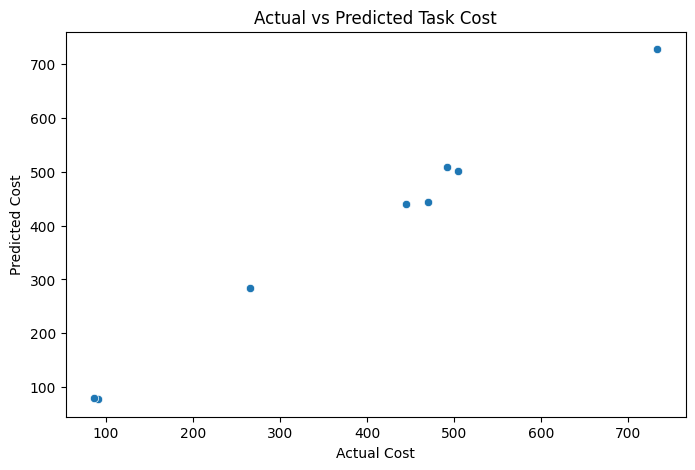

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Task Cost")
plt.show()

In [12]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to /Users/kanishkk/AndroidStudioProjects/ml-cost-prediction/models/task_cost_linear_regression.joblib


In [13]:
sample = pd.DataFrame([{
    "group_id": 1,
    "category_name": "equipment",
    "priority": "HIGH",
    "estimated_hours": 10.0,
    "team_size": 3,
    "allocated_amount": 350.0
}])

predicted_cost = model.predict(sample)[0]
print(f"Predicted task cost: {predicted_cost:.2f}")

Predicted task cost: 358.56


In [14]:
pip install tensorflow


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Us

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [16]:
X_processed = preprocessor.fit_transform(X)

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# Convert sparse matrix to dense if needed
if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()
if hasattr(X_test_nn, "toarray"):
    X_test_nn = X_test_nn.toarray()

X_train_nn.shape, X_test_nn.shape


((28, 13), (8, 13))

In [17]:
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)
])

nn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

nn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.2,
    epochs=100,
    batch_size=4,
    verbose=0
)


In [19]:
nn_predictions = nn_model.predict(X_test_nn).flatten()

nn_mae = mean_absolute_error(y_test_nn, nn_predictions)
nn_rmse = mean_squared_error(y_test_nn, nn_predictions) ** 0.5
nn_r2 = r2_score(y_test_nn, nn_predictions)

print("Neural Network Results")
print(f"MAE:  {nn_mae:.2f}")
print(f"RMSE: {nn_rmse:.2f}")
print(f"R2:   {nn_r2:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Neural Network Results
MAE:  134.50
RMSE: 177.27
R2:   0.28


In [20]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "MAE": [mae, nn_mae],
    "RMSE": [rmse, nn_rmse],
    "R2": [r2, nn_r2]
})

comparison


,Model,MAE,RMSE,R2
0,Linear Regression,12.176333,14.388284,0.995250
1,Neural Network,134.503318,177.273421,0.279025


In [21]:
import joblib
joblib.dump(model, "../models/task_cost_linear_regression.joblib")
print("Linear regression model saved.")


Linear regression model saved.
